In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import NullFormatter
import matplotlib

In [2]:
def permutacije(n, k):
    if k > n:
        return 0
    else:
        return math.factorial(n) // math.factorial(n - k)

In [3]:
def kombinacije(n, k):
    if k > n:
        return 0
    else:
        return math.factorial(n) // (math.factorial(k) * math.factorial(n - k))

In [4]:
primeri = [
    (5, 3),
    (10, 5),
    (7, 2),
    (8, 4),]
for n, k in primeri:
    print(f"Permutacije({n}, {k}) = {permutacije(n, k)}")
    print(f"Kombinacije({n}, {k}) = {kombinacije(n, k)}")  
    print('---')

Permutacije(5, 3) = 60
Kombinacije(5, 3) = 10
---
Permutacije(10, 5) = 30240
Kombinacije(10, 5) = 252
---
Permutacije(7, 2) = 42
Kombinacije(7, 2) = 21
---
Permutacije(8, 4) = 1680
Kombinacije(8, 4) = 70
---


<>:11: SyntaxWarning: invalid escape sequence '\c'
<>:12: SyntaxWarning: invalid escape sequence '\c'
<>:11: SyntaxWarning: invalid escape sequence '\c'
<>:12: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_8229/2298286226.py:11: SyntaxWarning: invalid escape sequence '\c'
  plt.text(0.0, 0.2, "$p(A \cap B)$", **text_kwargs)
/tmp/ipykernel_8229/2298286226.py:12: SyntaxWarning: invalid escape sequence '\c'
  plt.text(0, -2.3, "$p(A \cup B) = p(A) + p(B) - p(A \cap B)$", **text_kwargs)


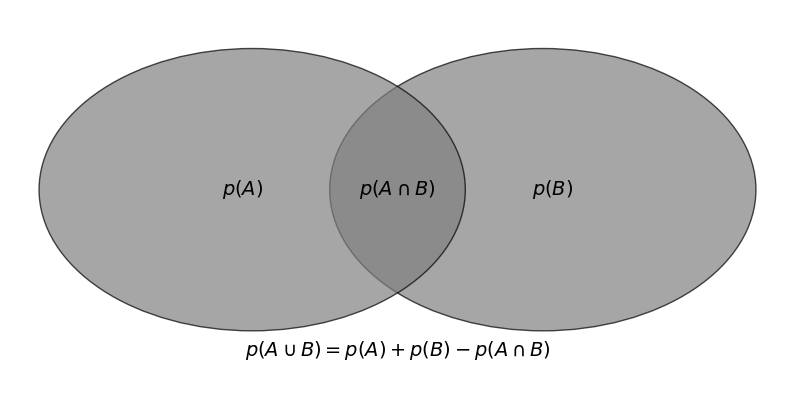

In [5]:
fig = plt.figure(figsize=(10, 5), facecolor='w')
plt.axis([-4, 4, -3, 3])
plt.axis('off')

plt.gca().add_patch(plt.Circle((1.5, 0.2), 2.2, fc='gray', ec='black', alpha=0.7))
plt.gca().add_patch(plt.Circle((-1.5, 0.2), 2.2, fc='gray', ec='black', alpha=0.7))

text_kwargs = dict(ha='center', va='center', fontsize=14)
plt.text(-1.6, 0.2, "$p(A)$", **text_kwargs)
plt.text(1.6, 0.2, "$p(B)$", **text_kwargs)
plt.text(0.0, 0.2, "$p(A \cap B)$", **text_kwargs)
plt.text(0, -2.3, "$p(A \cup B) = p(A) + p(B) - p(A \cap B)$", **text_kwargs)
plt.show()

In [ ]:
# Kocka se baca 2 puta. Naci verovatnocu da zbir bude 7, da prvi bude 6, i da prvi bude 6 ili zbir bude 7.
bacanja = np.arange(1, 7)
o1, o2 = np.meshgrid(bacanja, bacanja)
print(o1, o2)
o1 = o1.flatten()
o2 = o2.flatten()

n = len(o1)

def P(m):
    return np.sum(m) / n

A = (o1 + o2) == 7
L = o1 == 6
L_ili_A = L | A

print(f"P(A) = {P(A):.4f}")
print(f"P(1-A) = {P(~A):.4f}")
print(f"P(L ili A) = {P(L_ili_A):.4f}")

[[1 2 3 4 5 6]
 [1 2 3 4 5 6]
 [1 2 3 4 5 6]
 [1 2 3 4 5 6]
 [1 2 3 4 5 6]
 [1 2 3 4 5 6]] [[1 1 1 1 1 1]
 [2 2 2 2 2 2]
 [3 3 3 3 3 3]
 [4 4 4 4 4 4]
 [5 5 5 5 5 5]
 [6 6 6 6 6 6]]
P(A) = 0.1667
P(1-A) = 0.8333
P(L ili A) = 0.3056


In [8]:
# Naci verovatnocu da se bacanjem kocki dobije neparan broj veci od 2
bacanja = np.arange(1, 7)
A = bacanja % 2 == 1
B = bacanja > 2
n = len(bacanja)

P_B = np.sum(B) / n
P_A_uz_B = (A & B).sum() / B.sum()
P_A_i_B = P_A_uz_B * P_B

print(f"omega = {bacanja}")
print(f"A = {bacanja[A]}")
print(f"B (> 2) = {bacanja[B]}")
print(f"A presek B = {bacanja[A & B]}")
print(f"P(B) = {B.sum()}/{len(bacanja)} = {P_B:.4f}")
print(f"P(A|B) = {(A&B).sum()}/{B.sum()} = {P_A_uz_B:.4f}")
print(f"P(A presek B) = {P_B:.4f} x {P_A_uz_B:.4f} = {P_A_i_B:.4f}")


omega = [1 2 3 4 5 6]
A = [1 3 5]
B (> 2) = [3 4 5 6]
A presek B = [3 5]
P(B) = 4/6 = 0.6667
P(A|B) = 2/4 = 0.5000
P(A presek B) = 0.6667 x 0.5000 = 0.3333


In [9]:
# Postoji kutija u kojoj su tri vrećice sa klikerima. Jedna vrećica ima 3 zelena i 7 plavih klikera, druga ima 6 zelenih i 4 plava,
# dok posljednja ima 2 zelenih i 8 plavih klikera. Kolika je ukupna vjerovatnoća da se iz kutije izvuče zeleni kliker?
vrećice = np.array([[3, 7], [6, 4], [2, 8]])
ukupno = vrećice.sum(axis=1)
P_G_uz_B = vrećice[:, 0] / ukupno
P_B = np.ones(len(vrećice)) / vrećice.sum()
P_G = (P_G_uz_B * P_B).sum()

for i, (p_g, p_b) in enumerate(zip(P_G_uz_B, P_B)):
    print(f"P(G|B{i+1}) = {vrećice[i,0]}/{ukupno[i]} = {p_g:.4f}  |  P(B{i+1}) = {p_b:.4f}")

print(f"P(G) = {P_G:.4f}")

P(G|B1) = 3/10 = 0.3000  |  P(B1) = 0.0333
P(G|B2) = 6/10 = 0.6000  |  P(B2) = 0.0333
P(G|B3) = 2/10 = 0.2000  |  P(B3) = 0.0333
P(G) = 0.0367


In [ ]:
# 